### An Attempt at Supervised Learning Pipeline using retrieved and cross matched variable star table

**In this notebook, we will be loading in our finalized variable star catalog to be used for our machine learning pipeline which will first involve data cleaning / preparation, feature engineering, and pca. We will then test a random forest algorithm for classification**

Necessary Imports

In [10]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lsst.rsp import get_tap_service

import astropy.units as u
from astropy.table import unique
from astropy.coordinates import SkyCoord
import os

import scipy.stats as stats

# sklearn imports:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# pca
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [17]:
# load csv of classified variable stars we have created, see 'DP1Matching' Notebook for more info on this
path = os.getcwd()
# in case you have trouble finding this csv, it is the filtered catalog of classified variable stars and should be found in the same directory
# change path name as needed
variable_star_catalog_path = os.path.join(path, 'diaobject_matched_final.csv')

variable_star_catalog_path

'/home/aadi-bery/WORK/uploaded notebooks/diaobject_matched_final.csv'

In [18]:
# convert csv to a pandas df
v_star_catalog = pd.read_csv(v_star_catalog_path)

In [19]:
# print out shape and a few of the rows
print(v_star_catalog.shape)

v_star_catalog

(751, 27)


,index,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,...,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
0,0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True
1,1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True
2,2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,...,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae,RR*,True
3,3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,...,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True
4,4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,...,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,519,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,...,118.925003,26.686199,NaN,4.0,2.0,6,Fornax,RRLyrae,RR*,True
747,520,605446971188052409,40.524980,-34.175998,NaN,1201.327881,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,1.0,NaN,1,Fornax,RRLyrae,NaN,False
748,521,604071413422227523,40.579507,-34.425840,NaN,-216.893066,NaN,NaN,1418.954725,NaN,...,1003.349976,NaN,NaN,2.0,NaN,2,Fornax,RRLyrae,NaN,False
749,524,604064129157695647,39.842172,-34.335958,NaN,2537.979248,-1253.225342,NaN,154.972733,NaN,...,53.382801,0.000000,NaN,5.0,1.0,6,Fornax,RRLyrae,RR*,True


In [20]:
# drop the other unnecessary index column
v_star_catalog.drop(columns=['index'], inplace=True)

v_star_catalog.head()

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,...,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,...,NaN,5219.07,1.0,NaN,2.0,3,47,RRLyrae,RR*,True
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,...,NaN,0.00,1.0,NaN,1.0,2,47,RRLyrae,RR*,True
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,...,1478.85,4499.99,1.0,2.0,4.0,7,47,RRLyrae,RR*,True


#### Table Preparation: We now want to retrieve other columns from the diaobject table that would be useful for classification. These include:
- Amplitude (xPSFluxPercentile95 - xPSFluxPercentile05)
- PSFluxLinearSlope (stores slope of linear model fit to diaSource PSFlux vs time) → can be used to identify LPVs early on
- PSFMaxSlope (can look at all bands)
- PSFluxSkew (good indication of skewed light curve)
- PSFlux and Magnitudes (non-difference so we can convert to magnitudes) -> grab scienceFluxes in diaObject table
- Get corresponding color info from these averaged magnitudes (g-r, r-i, g-i)
- Also grab a reduced chi2 measurement (chi2 / n-1)


In [21]:
#store all diaobjectids in a list
v_star_diaobj_ids = v_star_catalog['diaObjectId'].tolist()
v_star_diaobj_ids[:5]

[579583227887354659,
 579574706672238627,
 579574569233285135,
 579575187708576418,
 579575256428052817]

In [22]:
# initialize tap
service = get_tap_service('tap')

In [23]:
# now we will try to query all of the objects in our catalog and retrieve the necessary columns / features
# we will use an ADQL query for this and match up to the diaObjectIds

id_list_str = ','.join(str(x) for x in v_star_diaobj_ids)

    
query = f'''SELECT diaObjectId, g_psfFluxPercentile95, r_psfFluxPercentile95, i_psfFluxPercentile95, 
        g_psfFluxPercentile50,r_psfFluxPercentile50, i_psfFluxPercentile50, 
        g_psfFluxPercentile05, r_psfFluxPercentile05, i_psfFluxPercentile05, 
        g_psfFluxLinearSlope, r_psfFluxLinearSlope, i_psfFluxLinearSlope,
        g_psfFluxMaxSlope, r_psfFluxMaxSlope, i_psfFluxMaxSlope,
        g_psfFluxSkew, r_psfFluxSkew, i_psfFluxSkew,
        g_scienceFluxMean, r_scienceFluxMean, i_scienceFluxMean,
        g_scienceFluxSigma, r_scienceFluxSigma, i_scienceFluxSigma,
        scisql_nanojanskyToAbMag(g_scienceFluxMean) AS gmag,
        scisql_nanojanskyToAbMag(r_scienceFluxMean) AS rmag,
        scisql_nanojanskyToAbMag(i_scienceFluxMean) AS imag
        FROM dp1.DiaObject
        WHERE diaObjectId IN ({id_list_str}) '''

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
results = job.fetch_result().to_table().to_pandas()

Job phase is COMPLETED


In [24]:
results

,diaObjectId,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,...,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag
0,579574706672238627,2142.085449,NaN,NaN,2142.085449,NaN,NaN,2142.085449,NaN,NaN,...,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN
1,579575393867006064,13587.747070,32999.347656,6635.610840,13587.747070,32999.347656,6635.610840,13587.747070,32999.347656,6635.610840,...,NaN,276892.468750,1.267242e+06,2.514130e+06,NaN,NaN,NaN,17.794222,16.142851,15.399031
2,579574637952761891,NaN,NaN,23666.055225,NaN,NaN,17725.198730,NaN,NaN,11784.342236,...,NaN,NaN,NaN,2.826738e+06,NaN,NaN,17997.812125,NaN,NaN,15.271786
3,579574637952761900,NaN,NaN,64125.707812,NaN,NaN,-373077.585938,NaN,NaN,-810280.856250,...,NaN,NaN,NaN,2.419296e+06,NaN,NaN,813141.950831,NaN,NaN,15.440777
4,579575256428053274,14746.224609,-25633.839844,NaN,14746.224609,-25633.839844,NaN,14746.224609,-25633.839844,NaN,...,NaN,507723.375000,2.151710e+06,NaN,NaN,NaN,NaN,17.135932,15.568041,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,604064197877171380,NaN,-1625.263928,NaN,NaN,-1632.613892,NaN,NaN,-1709.411401,NaN,...,NaN,NaN,1.015361e+04,NaN,NaN,87.161217,NaN,NaN,21.383449,NaN
747,604064197877171397,NaN,-1443.395361,NaN,NaN,-2021.823242,NaN,NaN,-2186.444092,NaN,...,NaN,NaN,8.609784e+03,NaN,NaN,738.000144,NaN,NaN,21.562519,NaN
748,604064266596646927,NaN,1105.045093,2472.758789,NaN,885.269531,2302.075195,NaN,-3070.689258,2131.391602,...,NaN,NaN,1.232173e+04,1.347851e+04,NaN,1875.391052,742.793577,NaN,21.173321,21.075895
749,604064266596646963,NaN,33821.939453,36255.921484,NaN,-5671.656982,28449.158203,NaN,-6383.144531,-38597.084570,...,-0.685584,NaN,1.472160e+05,4.844553e+05,NaN,38508.441697,57722.138102,NaN,18.480113,17.186866


In [25]:
# since the WHERE --- IN () doesnt guarantee order, we want to sort the result in the same order as the input list using a map
id_order = {id_: i for i, id_ in enumerate(v_star_diaobj_ids)} # maps each object id to its original position

# Sort results by the original order
results['original_index'] = results['diaObjectId'].map(id_order)
results.sort_values('original_index', inplace=True)
results.drop(columns='original_index', inplace=True)

results

,diaObjectId,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,...,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag
40,579583227887354659,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,6659.355957,NaN,...,NaN,NaN,54098.902344,NaN,NaN,NaN,NaN,NaN,19.567029,NaN
0,579574706672238627,2142.085449,NaN,NaN,2142.085449,NaN,NaN,2142.085449,NaN,NaN,...,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN
14,579574569233285135,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,...,NaN,29299.523438,NaN,47978.964844,NaN,NaN,8083.117155,20.232849,NaN,19.697373
12,579575187708576418,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,...,NaN,52186.820312,NaN,50817.039062,NaN,NaN,NaN,19.606098,NaN,19.634977
6,579575256428052817,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,...,0.013991,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,604072100616995077,NaN,-2000.293219,1353.706140,NaN,-2453.593628,1329.688599,NaN,-2587.836597,1305.671057,...,NaN,NaN,10547.983398,13234.293945,NaN,391.205239,128.230086,NaN,21.342076,21.095748
145,605446971188052409,NaN,1201.327881,NaN,NaN,1201.327881,NaN,NaN,1201.327881,NaN,...,NaN,NaN,8655.055664,NaN,NaN,NaN,NaN,NaN,21.556825,NaN
419,604071413422227523,NaN,813.372571,NaN,NaN,-89.644714,NaN,NaN,-992.661938,NaN,...,NaN,NaN,9401.547852,NaN,NaN,1806.606726,NaN,NaN,21.467002,NaN
64,604064129157695647,NaN,2726.801562,-1253.225342,NaN,2524.800781,-1253.225342,NaN,2367.083838,-1253.225342,...,NaN,NaN,13912.183594,10713.960938,NaN,297.282728,NaN,NaN,21.041512,21.325125


In [26]:
# now want to merge these additional features with the original catalog based on diaObjectId
merged_df = v_star_catalog.merge(results, on='diaObjectId', how='left')

In [27]:
merged_df

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,54098.902344,NaN,NaN,NaN,NaN,NaN,19.567029,NaN
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,...,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,...,NaN,29299.523438,NaN,47978.964844,NaN,NaN,8083.117155,20.232849,NaN,19.697373
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,...,NaN,52186.820312,NaN,50817.039062,NaN,NaN,NaN,19.606098,NaN,19.634977
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,...,0.013991,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,NaN,...,NaN,NaN,10547.983398,13234.293945,NaN,391.205239,128.230086,NaN,21.342076,21.095748
747,605446971188052409,40.524980,-34.175998,NaN,1201.327881,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8655.055664,NaN,NaN,NaN,NaN,NaN,21.556825,NaN
748,604071413422227523,40.579507,-34.425840,NaN,-216.893066,NaN,NaN,1418.954725,NaN,NaN,...,NaN,NaN,9401.547852,NaN,NaN,1806.606726,NaN,NaN,21.467002,NaN
749,604064129157695647,39.842172,-34.335958,NaN,2537.979248,-1253.225342,NaN,154.972733,NaN,NaN,...,NaN,NaN,13912.183594,10713.960938,NaN,297.282728,NaN,NaN,21.041512,21.325125


In [28]:
# adding columns for color, amplitudes, as well as normalized sigma for each band respectively
merged_df['g_r'] = merged_df['gmag'] - merged_df['rmag'] # column for g-r (blue stars will usually have low g-r, red stars high g-r)
merged_df['r_i'] = merged_df['rmag'] - merged_df['imag'] # column for r-i
merged_df['g_i'] = merged_df['gmag'] - merged_df['imag'] # column for g-i

merged_df['amp_g'] = merged_df['g_psfFluxPercentile95'] - merged_df['g_psfFluxPercentile05']# one option is to then calculate the magnitude of this (problematic)
merged_df['amp_r'] = merged_df['r_psfFluxPercentile95'] - merged_df['r_psfFluxPercentile05']
merged_df['amp_i'] = merged_df['r_psfFluxPercentile95'] - merged_df['i_psfFluxPercentile05']
merged_df['g_red_chi2'] = merged_df['g_psfFluxChi2'] / (merged_df['g_psfFluxNdata'] - 1)
merged_df['r_red_chi2'] = merged_df['r_psfFluxChi2'] / (merged_df['r_psfFluxNdata'] - 1)
merged_df['i_red_chi2'] = merged_df['i_psfFluxChi2'] / (merged_df['i_psfFluxNdata'] - 1)

# modify our psf flux sigma so that it is more representative of the percentile of variation
merged_df['g_psfFluxSigma_norm'] = merged_df['g_psfFluxSigma'] / merged_df['g_psfFluxMean'] # can convert this into a magnitude based version
merged_df['r_psfFluxSigma_norm'] = merged_df['r_psfFluxSigma'] / merged_df['r_psfFluxMean']
merged_df['i_psfFluxSigma_norm'] = merged_df['i_psfFluxSigma'] / merged_df['i_psfFluxMean']

merged_df['r_psfFluxMAD_rel'] = (1.4826 * merged_df['r_psfFluxMAD']) / merged_df['r_scienceFluxMean'] # how much source's diff flux varies relative to the total flux
merged_df['g_psfFluxMAD_rel'] = (1.4826 * merged_df['g_psfFluxMAD']) / merged_df['g_scienceFluxMean']
merged_df['i_psfFluxMAD_rel'] = (1.4826 * merged_df['i_psfFluxMAD']) / merged_df['i_scienceFluxMean']

# Science flux percentage of variation
merged_df['g_scienceFluxSigma_norm'] = merged_df['g_scienceFluxSigma'] / merged_df['g_scienceFluxMean']
merged_df['r_scienceFluxSigma_norm'] = merged_df['r_scienceFluxSigma'] / merged_df['r_scienceFluxMean']
merged_df['i_scienceFluxSigma_norm'] = merged_df['i_scienceFluxSigma'] / merged_df['i_scienceFluxMean']

# calculate wesenheit magnitudes
merged_df['W_mag_r_ri'] = merged_df['rmag'] - (4.051 * merged_df['r_i'])
merged_df['W_mag_gr'] = merged_df['rmag'] - (2.905 * merged_df['g_r']) # both of these are relatively the same
merged_df['W_mag_i_ri'] = merged_df['imag'] - (5.379 * merged_df['r_i'])
merged_df['W_mag_gi'] = merged_df['gmag'] - (2.274 * merged_df['g_i'])

In [29]:
pd.set_option('display.max_columns', None) # set to display all columns
merged_df

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54098.902344,NaN,NaN,NaN,NaN,NaN,19.567029,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True,2142.085449,NaN,NaN,2142.085449,NaN,NaN,2142.085449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.26800,NaN,NaN,15.224242,0.0,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae,RR*,True,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,NaN,NaN,-868.516082,NaN,NaN,-8.683926e+02,NaN,NaN,NaN,29299.523438,NaN,47978.964844,NaN,NaN,8083.117155,20.232849,NaN,19.697373,NaN,NaN,0.535476,0.0,NaN,NaN,inf,NaN,254.268000,NaN,NaN,-959.090718,NaN,0.0,0.161275,NaN,NaN,0.168472,NaN,NaN,NaN,19.015177
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,NaN,0.00000,NaN,NaN,NaN,0.0,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52186.820312,NaN,50817.039062,NaN,NaN,NaN,19.606098,NaN,19.634977,NaN,NaN,-0.028879,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,19.671768
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.44600,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,NaN,-589.070678,759.578197,NaN,-589.170293,1.353681e+06,NaN,NaN,0.013991,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.0,2661.922705,-282.140698,NaN,36.384200,174.148667,NaN,-0.308456,-6.606807,0.052061,0.0,0.145805,NaN,0.016431,0.112839,19.474029,19.100303,19.264337,19.310167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,NaN,9.630550,0.02401,NaN,0.422049,-

In [31]:
# save this dataframe (contains all features and all stars before filtering)
merged_df.to_csv('variablestar_all_feat.csv', index=False)

### Data Cleaning and Feature Engineering
Now that we have all of the features of interest for every star in that catalog, we need to perform data cleaning and feature engineering

In [21]:
# get subset of all stars which have at least 4 diaSource detections
merged_df_subset = merged_df[(merged_df['nDiaSources'] > 3)]
merged_df_subset

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.446000,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,NaN,-589.070678,759.578197,NaN,-5.891703e+02,1.353681e+06,NaN,NaN,0.013991,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.000000,2661.922705,-282.140698,NaN,36.384200,174.148667,NaN,-0.308456,-6.606807,0.052061,0.000000,0.145805,NaN,0.016431,0.112839,19.474029,19.100303,19.264337,19.310167
5,579575256428052807,6.028941,-72.575914,4831.474609,-25320.785156,-179.425217,NaN,30822.791670,12747.179363,1.633590e-12,5837.170000,4387.010000,NaN,67.365384,14.667108,0.0,21795.000000,1060.870000,1.0,2.0,6.0,9,47,RRLyrae,RR*,True,4831.475098,113.860986,7076.623047,4831.475098,-19501.644287,4804.219238,4831.475098,-39117.147852,-18428.811035,NaN,3957.027722,915.011223,NaN,3.956014e+03,4.433660e+06,NaN,NaN,-2.390770,94495.656250,73381.914062,83378.773438,NaN,33545.521350,11401.191513,18.961470,19.236027,19.097361,-0.274557,0.138666,-0.135891,0.000000,39231.008838,18542.672021,inf,5837.170000,877.402000,NaN,-1.217292,-71.044525,0.440344,0.000000,0.018864,NaN,0.457136,0.136740,18.674291,20.033616,18.351476,19.270486
6,579575256428052608,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,0.000000e+00,23896.600000,3197.090000,NaN,43.766055,21.391475,0.0,7401.710000,1991.170000,1.0,10.0,4.0,15,47,RRLyrae,RR*,True,3551.469238,38994.763281,19067.249121,3551.469238,-5791.553955,-6033.679688,3551.469238,-13202.357617,-8143.472314,NaN,-2118.933673,-2688.534241,NaN,3.390524e+06,1.824429e+06,NaN,1.306770,1.916990,48699.910156,71115.671875,60267.218750,NaN,20358.782126,30144.760459,19.681180,19.270087,19.449797,0.411093,-0.179710,0.231382,0.000000,52197.120898,47138.235596,NaN,2655.177778,1065.696667,NaN,8.899072,-22.049331,0.154309,0.000000,0.048984,NaN,0.286277,0.500185,19.998094,18.075862,20.416459,19.155016
7,579575256428052935,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,9.085750e+03,12708.900000,5545.660000,91.219314,33.282176,24.862708,23838.8,6484.890000,1207.250000,2.0,8.0,4.0,14,47,RRLyrae,RR*,True,20898.193750,21044.452930,4280.432800,-556.765625,-8482.533936,2385.933716,-22011.726953,-15661.032666,-29527.344727,7927.920396,2113.773047,3448.378869,7.930342e+03,4.964968e+06,1.101634e+06,NaN,1.102430,-1.981840,61150.265625,54424.007812,54046.925781,33382.845358,15685.787582,19297.797066,19.434004,19.560524,19.568073,-0.126520,-0.007549,-0.134068,42909.920703,36705.485596,50571.797656,9085.750000,1815.557143,1848.553333,-13.710925,-3.835548,-4.067157,0.176659,0.577976,0.03311

In [22]:
# save this merged susbet as a csv
merged_df_subset.to_csv('variablestar_filtered.csv', index=False)

# look at distribution of star classes
merged_df_subset['Class'].value_counts()

Class
RRLyrae    354
LPV        179
Cepheid     16
Name: count, dtype: int64

In [23]:
# check the distribution of missing values across each column (we will likely keep ones with minimal missing values
pd.set_option('display.max_rows', None)
merged_df_subset.isna().sum()

diaObjectId                  0
ra                           0
dec                          0
g_psfFluxMean              416
r_psfFluxMean               14
i_psfFluxMean              109
g_psfFluxSigma             458
r_psfFluxSigma              23
i_psfFluxSigma             171
g_psfFluxChi2              416
r_psfFluxChi2               14
i_psfFluxChi2              109
g_psfFluxStetsonJ          458
r_psfFluxStetsonJ           23
i_psfFluxStetsonJ          171
g_psfFluxMAD               416
r_psfFluxMAD                14
i_psfFluxMAD               109
g_psfFluxNdata             416
r_psfFluxNdata              14
i_psfFluxNdata             109
nDiaSources                  0
Region                       0
Class                        0
otype                      100
otype_flag                   0
g_psfFluxPercentile95      416
r_psfFluxPercentile95       14
i_psfFluxPercentile95      109
g_psfFluxPercentile50      416
r_psfFluxPercentile50       14
i_psfFluxPercentile50      109
g_psfFlu

In [24]:
# try plotting a color magnitude diagram for each of the star types (color code by star)
pd.reset_option('display.max_rows')

df_colmags = merged_df_subset[['r_i', 'rmag', 'W_mag_r_ri', 'W_mag_i_ri', 'Region', 'Class']]
df_colmags['W_r_i'] = merged_df_subset['W_mag_r_ri'] - merged_df_subset['W_mag_i_ri']

df_colmags.dropna()

/tmp/ipykernel_127/2470476689.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags['W_r_i'] = merged_df_subset['W_mag_r_ri'] - merged_df_subset['W_mag_i_ri']


,r_i,rmag,W_mag_r_ri,W_mag_i_ri,Region,Class,W_r_i
4,0.090074,19.838917,19.474029,19.264337,47,RRLyrae,0.209691
5,0.138666,19.236027,18.674291,18.351476,47,RRLyrae,0.322815
6,-0.179710,19.270087,19.998094,20.416459,47,RRLyrae,-0.418366
7,-0.007549,19.560524,19.591104,19.608678,47,RRLyrae,-0.017574
8,-0.083112,19.463617,19.800302,19.993786,47,RRLyrae,-0.193484
...,...,...,...,...,...,...,...
743,0.230043,21.485736,20.553832,20.018292,Fornax,RRLyrae,0.535540
744,0.196629,21.456746,20.660201,20.202449,Fornax,RRLyrae,0.457752
745,0.194588,21.440610,20.652335,20.199334,Fornax,RRLyrae,0.453001
746,0.246328,21.342076,20.344200,19.770748,Fornax,RRLyrae,0.573452


In [25]:
print(df_colmags['Class'].value_counts())
print(df_colmags['Region'].value_counts())

Class
RRLyrae    354
LPV        179
Cepheid     16
Name: count, dtype: int64
Region
Fornax     438
47          73
Seagull     27
LGLF         7
LELF         3
EDFS         1
Name: count, dtype: int64


In [26]:
color_map = {
    'RRLyrae': 'red',
    'LPV': 'green',
    'Cepheid': 'blue'
}

symbol_map = {
    '47': 'o',
    'Fornax': 'v',
    'Seagull': '^',
    'LGLF': '*',
    'LELF': 'p',
    'EDFS': '+'
}

df_colmags['color'] = df_colmags['Class'].map(color_map)

df_colmags['symbol'] = df_colmags['Region'].map(symbol_map)

df_colmags

/tmp/ipykernel_127/2984398776.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags['color'] = df_colmags['Class'].map(color_map)
/tmp/ipykernel_127/2984398776.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags['symbol'] = df_colmags['Region'].map(symbol_map)


,r_i,rmag,W_mag_r_ri,W_mag_i_ri,Region,Class,W_r_i,color,symbol
4,0.090074,19.838917,19.474029,19.264337,47,RRLyrae,0.209691,red,o
5,0.138666,19.236027,18.674291,18.351476,47,RRLyrae,0.322815,red,o
6,-0.179710,19.270087,19.998094,20.416459,47,RRLyrae,-0.418366,red,o
7,-0.007549,19.560524,19.591104,19.608678,47,RRLyrae,-0.017574,red,o
8,-0.083112,19.463617,19.800302,19.993786,47,RRLyrae,-0.193484,red,o
...,...,...,...,...,...,...,...,...,...
744,0.196629,21.456746,20.660201,20.202449,Fornax,RRLyrae,0.457752,red,v
745,0.194588,21.440610,20.652335,20.199334,Fornax,RRLyrae,0.453001,red,v
746,0.246328,21.342076,20.344200,19.770748,Fornax,RRLyrae,0.573452,red,v
749,-0.283613,21.041512,22.190428,22.850680,Fornax,RRLyrae,-0.660251,red,v


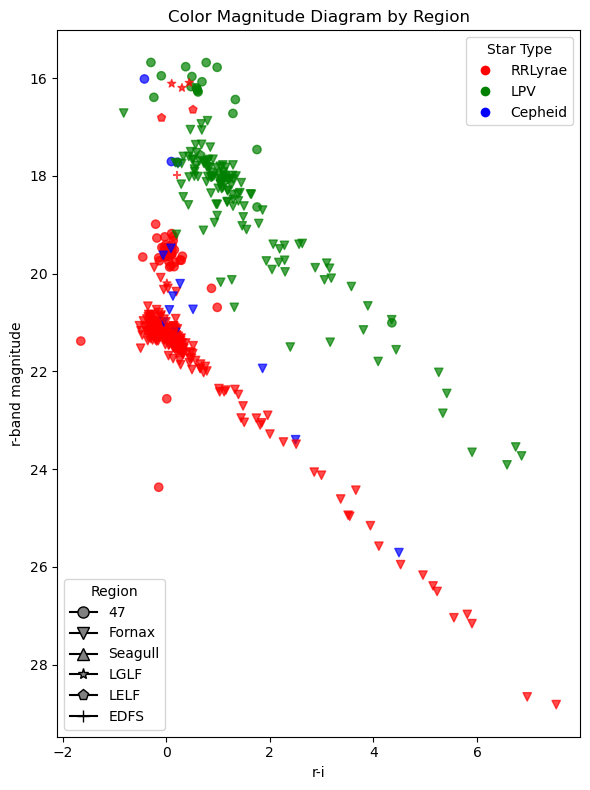

In [27]:
from matplotlib.lines import Line2D

plt.figure(figsize=(6,8))
for region, group in df_colmags.groupby('Region'):
    plt.scatter(
        group['r_i'],
        group['rmag'],
        c=group['color'],
        marker=symbol_map[region],
        label=region,
        alpha=0.7
    )

class_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cls, 
           markerfacecolor = col, markersize=8)
        for cls, col in color_map.items()
]

region_legend_elements = [
    Line2D([0], [0], marker=marker, color='k', label=region,
           markerfacecolor='gray', markersize=8)
        for region, marker in symbol_map.items()
]
    
# plt.scatter(x=df_colmags['r_i'], y=df_colmags['rmag'], c=df_colmags['color'], marker=11, cmap='Set1', alpha=0.7)
plt.xlabel('r-i')
plt.ylabel('r-band magnitude')
plt.title('Color Magnitude Diagram by Region')

legend1 = plt.legend(handles=class_legend_elements, title="Star Type", loc='upper right')
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles=region_legend_elements, title="Region", loc='lower left')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

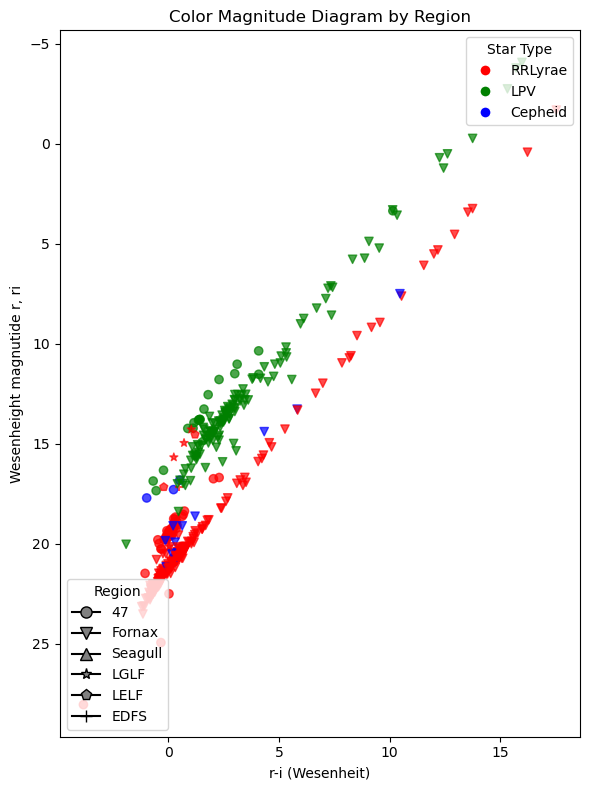

In [28]:
plt.figure(figsize=(6,8))
for region, group in df_colmags.groupby('Region'):
    plt.scatter(
        group['W_r_i'],
        group['W_mag_r_ri'],
        c=group['color'],
        marker=symbol_map[region],
        label=region,
        alpha=0.7
    )

class_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cls, 
           markerfacecolor = col, markersize=8)
        for cls, col in color_map.items()
]

region_legend_elements = [
    Line2D([0], [0], marker=marker, color='k', label=region,
           markerfacecolor='gray', markersize=8)
        for region, marker in symbol_map.items()
]
    
# plt.scatter(x=df_colmags['r_i'], y=df_colmags['rmag'], c=df_colmags['color'], marker=11, cmap='Set1', alpha=0.7)
plt.xlabel('r-i (Wesenheit)')
plt.ylabel('Wesenheight magnutide r, ri')
plt.title('Color Magnitude Diagram by Region')

legend1 = plt.legend(handles=class_legend_elements, title="Star Type", loc='upper right')
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles=region_legend_elements, title="Region", loc='lower left')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

### Note: It is clear there are inherently issues with both the color and magnitude information (stems from the psfFlux info) as there are unusually high magnitudes and too much noise. Even after retrieving objects with enough observations (by DP1 standards) we picked up a lot of noise. Thus, this is our primary motivation in grabbing data from ForcedSourceOnDiaObject and aggregating them together to create summary statistics and magnitude measurements that are more reliable.

However, since we have gotten this far, let's still attempt our supervised ML pipeline with Random Forests.

In [29]:
# lets define our features to use for PCA / ML
features_subset = ['r_psfFluxSigma_norm', 'r_red_chi2', 'r_psfFluxStetsonJ', 'r_psfFluxMAD_rel', 'r_psfFluxLinearSlope',
                   'r_psfFluxMaxSlope', 'r_scienceFluxSigma_norm', 'amp_r', 'r_i', 'W_mag_r_ri', 'Region', 'Class']

In [30]:
df_ml = merged_df_subset[features_subset]

df_ml

,r_psfFluxSigma_norm,r_red_chi2,r_psfFluxStetsonJ,r_psfFluxMAD_rel,r_psfFluxLinearSlope,r_psfFluxMaxSlope,r_scienceFluxSigma_norm,amp_r,r_i,W_mag_r_ri,Region,Class
4,-0.308456,36.384200,4.992266,0.052061,-589.070678,-5.891703e+02,0.016431,2661.922705,0.090074,19.474029,47,RRLyrae
5,-1.217292,5837.170000,67.365384,0.440344,3957.027722,3.956014e+03,0.457136,39231.008838,0.138666,18.674291,47,RRLyrae
6,8.899072,2655.177778,43.766055,0.154309,-2118.933673,3.390524e+06,0.286277,52197.120898,-0.179710,19.998094,47,RRLyrae
7,-3.835548,1815.557143,33.282176,0.176659,2113.773047,4.964968e+06,0.288214,36705.485596,-0.007549,19.591104,47,RRLyrae
8,-5.437338,936.900000,25.344947,0.257532,-752.536473,1.476637e+06,0.166833,27545.775830,-0.083112,19.800302,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...
744,-0.363607,32.336498,2.539342,0.009585,-191.111954,7.807053e+05,0.089945,1889.907874,0.196629,20.660201,Fornax,RRLyrae
745,-0.045113,1.899980,0.633545,0.025616,-159717.314926,7.020733e+05,0.042421,466.662817,0.194588,20.652335,Fornax,RRLyrae
746,-0.127908,3.210183,0.422049,0.016716,49095.554437,4.681192e+05,0.037088,587.543378,0.246328,20.344200,Fornax,RRLyrae
749,0.061061,0.707963,-0.253267,0.005689,-27366.346880,5.942252e+05,0.021369,359.717725,-0.283613,22.190428,Fornax,RRLyrae


In [31]:
df_ml.isna().sum()

r_psfFluxSigma_norm         23
r_red_chi2                  21
r_psfFluxStetsonJ           23
r_psfFluxMAD_rel            14
r_psfFluxLinearSlope        23
r_psfFluxMaxSlope           23
r_scienceFluxSigma_norm     23
amp_r                       14
r_i                        115
W_mag_r_ri                 115
Region                       0
Class                        0
dtype: int64

In [32]:
# drop all na values
df_ml = df_ml.dropna()

In [33]:
df_ml = df_ml.reset_index()
df_ml.drop(columns='index', inplace=True)
df_ml

,r_psfFluxSigma_norm,r_red_chi2,r_psfFluxStetsonJ,r_psfFluxMAD_rel,r_psfFluxLinearSlope,r_psfFluxMaxSlope,r_scienceFluxSigma_norm,amp_r,r_i,W_mag_r_ri,Region,Class
0,-0.308456,36.384200,4.992266,0.052061,-589.070678,-5.891703e+02,0.016431,2661.922705,0.090074,19.474029,47,RRLyrae
1,-1.217292,5837.170000,67.365384,0.440344,3957.027722,3.956014e+03,0.457136,39231.008838,0.138666,18.674291,47,RRLyrae
2,8.899072,2655.177778,43.766055,0.154309,-2118.933673,3.390524e+06,0.286277,52197.120898,-0.179710,19.998094,47,RRLyrae
3,-3.835548,1815.557143,33.282176,0.176659,2113.773047,4.964968e+06,0.288214,36705.485596,-0.007549,19.591104,47,RRLyrae
4,-5.437338,936.900000,25.344947,0.257532,-752.536473,1.476637e+06,0.166833,27545.775830,-0.083112,19.800302,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...
421,-0.466767,150.973999,6.390758,0.039829,-393.708300,-3.689461e+02,0.054474,3689.576233,0.230043,20.553832,Fornax,RRLyrae
422,-0.363607,32.336498,2.539342,0.009585,-191.111954,7.807053e+05,0.089945,1889.907874,0.196629,20.660201,Fornax,RRLyrae
423,-0.045113,1.899980,0.633545,0.025616,-159717.314926,7.020733e+05,0.042421,466.662817,0.194588,20.652335,Fornax,RRLyrae
424,-0.127908,3.210183,0.422049,0.016716,49095.554437,4.681192e+05,0.037088,587.543378,0.246328,20.344200,Fornax,RRLyrae


In [34]:
df_ml['Class'].value_counts()

Class
RRLyrae    268
LPV        143
Cepheid     15
Name: count, dtype: int64

**Perform one hot encoding for the region variable**

In [35]:
df_ml['Region'].unique()

array(['47', 'LELF', 'Fornax', 'EDFS', 'LGLF'], dtype=object)

In [36]:
df_regions = pd.get_dummies(df_ml['Region'], prefix='Region_')
df_regions

,Region__47,Region__EDFS,Region__Fornax,Region__LELF,Region__LGLF
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False
...,...,...,...,...,...
421,False,False,True,False,False
422,False,False,True,False,False
423,False,False,True,False,False
424,False,False,True,False,False


In [37]:
# join with original df
df_ml = df_ml.join(df_regions)

df_ml

,r_psfFluxSigma_norm,r_red_chi2,r_psfFluxStetsonJ,r_psfFluxMAD_rel,r_psfFluxLinearSlope,r_psfFluxMaxSlope,r_scienceFluxSigma_norm,amp_r,r_i,W_mag_r_ri,Region,Class,Region__47,Region__EDFS,Region__Fornax,Region__LELF,Region__LGLF
0,-0.308456,36.384200,4.992266,0.052061,-589.070678,-5.891703e+02,0.016431,2661.922705,0.090074,19.474029,47,RRLyrae,True,False,False,False,False
1,-1.217292,5837.170000,67.365384,0.440344,3957.027722,3.956014e+03,0.457136,39231.008838,0.138666,18.674291,47,RRLyrae,True,False,False,False,False
2,8.899072,2655.177778,43.766055,0.154309,-2118.933673,3.390524e+06,0.286277,52197.120898,-0.179710,19.998094,47,RRLyrae,True,False,False,False,False
3,-3.835548,1815.557143,33.282176,0.176659,2113.773047,4.964968e+06,0.288214,36705.485596,-0.007549,19.591104,47,RRLyrae,True,False,False,False,False
4,-5.437338,936.900000,25.344947,0.257532,-752.536473,1.476637e+06,0.166833,27545.775830,-0.083112,19.800302,47,RRLyrae,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,-0.466767,150.973999,6.390758,0.039829,-393.708300,-3.689461e+02,0.054474,3689.576233,0.230043,20.553832,Fornax,RRLyrae,False,False,True,False,False
422,-0.363607,32.336498,2.539342,0.009585,-191.111954,7.807053e+05,0.089945,1889.907874,0.196629,20.660201,Fornax,RRLyrae,False,False,True,False,False
423,-0.045113,1.899980,0.633545,0.025616,-159717.314926,7.020733e+05,0.042421,466.662817,0.194588,20.652335,Fornax,RRLyrae,False,False,True,False,False
424,-0.127908,3.210183,0.422049,0.016716,49095.554437,4.681192e+05,0.037088,587.543378,0.246328,20.344200,Fornax,RRLyrae,False,False,True,False,False


In [38]:
df_ml.dtypes

r_psfFluxSigma_norm        float64
r_red_chi2                 float64
r_psfFluxStetsonJ          float64
r_psfFluxMAD_rel           float64
r_psfFluxLinearSlope       float64
r_psfFluxMaxSlope          float64
r_scienceFluxSigma_norm    float64
amp_r                      float64
r_i                        float64
W_mag_r_ri                 float64
Region                      object
Class                       object
Region__47                    bool
Region__EDFS                  bool
Region__Fornax                bool
Region__LELF                  bool
Region__LGLF                  bool
dtype: object

In [39]:
# split our df into x and y
numer_cols = df_ml.select_dtypes(include=['float64']).columns.tolist()

df_numer = df_ml[numer_cols]
y = df_ml['Class']

df_numer

,r_psfFluxSigma_norm,r_red_chi2,r_psfFluxStetsonJ,r_psfFluxMAD_rel,r_psfFluxLinearSlope,r_psfFluxMaxSlope,r_scienceFluxSigma_norm,amp_r,r_i,W_mag_r_ri
0,-0.308456,36.384200,4.992266,0.052061,-589.070678,-5.891703e+02,0.016431,2661.922705,0.090074,19.474029
1,-1.217292,5837.170000,67.365384,0.440344,3957.027722,3.956014e+03,0.457136,39231.008838,0.138666,18.674291
2,8.899072,2655.177778,43.766055,0.154309,-2118.933673,3.390524e+06,0.286277,52197.120898,-0.179710,19.998094
3,-3.835548,1815.557143,33.282176,0.176659,2113.773047,4.964968e+06,0.288214,36705.485596,-0.007549,19.591104
4,-5.437338,936.900000,25.344947,0.257532,-752.536473,1.476637e+06,0.166833,27545.775830,-0.083112,19.800302
...,...,...,...,...,...,...,...,...,...,...
421,-0.466767,150.973999,6.390758,0.039829,-393.708300,-3.689461e+02,0.054474,3689.576233,0.230043,20.553832
422,-0.363607,32.336498,2.539342,0.009585,-191.111954,7.807053e+05,0.089945,1889.907874,0.196629,20.660201
423,-0.045113,1.899980,0.633545,0.025616,-159717.314926,7.020733e+05,0.042421,466.662817,0.194588,20.652335
424,-0.127908,3.210183,0.422049,0.016716,49095.554437,4.681192e+05,0.037088,587.543378,0.246328,20.344200


### Apply Principal Component Analysis to see which features have most predictive power and visualize data in 2 dimensions

In [40]:
# Apply standardization to all of our numerical columns which have very high values (all flux stuff in nanojanskys), this will be for pca
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numer)

print(df_scaled[:2])

[[ 0.04577121 -0.15590036 -0.29748523 -0.16715105  0.05854246 -0.13104883
  -0.22542321 -0.28432144 -0.50411655  0.44107346]
 [ 0.03956544  0.9552424   3.21052211  0.13708231  0.07290733 -0.13099967
  -0.18609266  0.40863164 -0.46809811  0.28485914]]


In [41]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(df_pca[:2])

[[-0.56579734 -0.59427502]
 [ 2.20235257 -0.81708904]]


In [42]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.30829327 0.29706079]
Cumulative: [0.30829327 0.60535406]


In [43]:
# create a label encoder for the categorical features
le = LabelEncoder()
y_encoded = le.fit_transform(y)

classes = le.classes_
classes

array(['Cepheid', 'LPV', 'RRLyrae'], dtype=object)

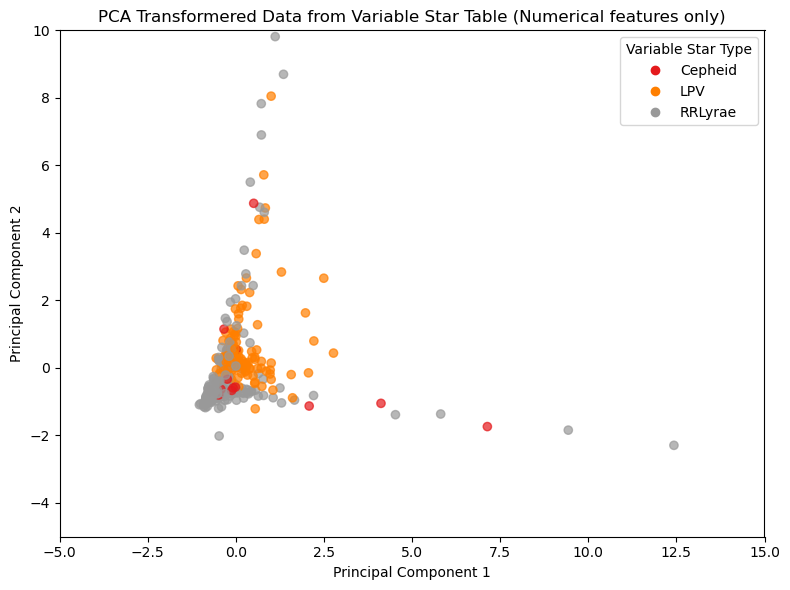

In [44]:
# create a visualization and cluster based on star type / 'Class'
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=y_encoded, cmap='Set1', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformered Data from Variable Star Table (Numerical features only)')

# set boundaries to avoid extreme outliers
plt.xlim(-5, 15) 
plt.ylim(-5, 10)

handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=scatter.cmap(scatter.norm(i)), label=label)
    for i, label in enumerate(classes)
]

plt.legend(handles=handles, title='Variable Star Type')

plt.tight_layout()
plt.show()

In [45]:
# check how much each feature is contributing to the variance / pca analysis
print(pca.components_) # n_components * n_features (2 x 12)

components_abs = np.abs(pca.components_.T) # now shape is n_features * n_components (can see how much each feature contributes to each PC)
components_norm = components_abs / components_abs.sum(axis=0) # normalize features column wise, so each value shows fractional contributions of feature to that component
# each column should sum up to 1

df_contrib = pd.DataFrame(components_norm, index=numer_cols, columns=['PC 1', 'PC 2'])
df_contrib

[[-0.02901244  0.52062027  0.50403785  0.05340992 -0.04555091  0.37531103
   0.06395705  0.54485133  0.07672936 -0.14639644]
 [-0.19289399 -0.11079332 -0.07668629  0.41317307 -0.01802875 -0.05130376
   0.50147993 -0.1015191   0.53310313 -0.47432022]]


,PC 1,PC 2
r_psfFluxSigma_norm,0.012294,0.077990
r_red_chi2,0.220613,0.044796
r_psfFluxStetsonJ,0.213587,0.031006
r_psfFluxMAD_rel,0.022633,0.167053
r_psfFluxLinearSlope,0.019302,0.007289
r_psfFluxMaxSlope,0.159038,0.020743
r_scienceFluxSigma_norm,0.027102,0.202757
amp_r,0.230881,0.041046
r_i,0.032514,0.215543
W_mag_r_ri,0.062036,0.191776


### Supervised Machine Learning - Random Forest / Linear Classifiers

In [46]:
# retrieve the dataframe with features we want from earlier (df_ml)
features = df_ml.columns.tolist()

features

['r_psfFluxSigma_norm',
 'r_red_chi2',
 'r_psfFluxStetsonJ',
 'r_psfFluxMAD_rel',
 'r_psfFluxLinearSlope',
 'r_psfFluxMaxSlope',
 'r_scienceFluxSigma_norm',
 'amp_r',
 'r_i',
 'W_mag_r_ri',
 'Region',
 'Class',
 'Region__47',
 'Region__EDFS',
 'Region__Fornax',
 'Region__LELF',
 'Region__LGLF']

In [47]:
df_ml.drop(columns='Region', axis=1, inplace=True)

df_ml

,r_psfFluxSigma_norm,r_red_chi2,r_psfFluxStetsonJ,r_psfFluxMAD_rel,r_psfFluxLinearSlope,r_psfFluxMaxSlope,r_scienceFluxSigma_norm,amp_r,r_i,W_mag_r_ri,Class,Region__47,Region__EDFS,Region__Fornax,Region__LELF,Region__LGLF
0,-0.308456,36.384200,4.992266,0.052061,-589.070678,-5.891703e+02,0.016431,2661.922705,0.090074,19.474029,RRLyrae,True,False,False,False,False
1,-1.217292,5837.170000,67.365384,0.440344,3957.027722,3.956014e+03,0.457136,39231.008838,0.138666,18.674291,RRLyrae,True,False,False,False,False
2,8.899072,2655.177778,43.766055,0.154309,-2118.933673,3.390524e+06,0.286277,52197.120898,-0.179710,19.998094,RRLyrae,True,False,False,False,False
3,-3.835548,1815.557143,33.282176,0.176659,2113.773047,4.964968e+06,0.288214,36705.485596,-0.007549,19.591104,RRLyrae,True,False,False,False,False
4,-5.437338,936.900000,25.344947,0.257532,-752.536473,1.476637e+06,0.166833,27545.775830,-0.083112,19.800302,RRLyrae,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,-0.466767,150.973999,6.390758,0.039829,-393.708300,-3.689461e+02,0.054474,3689.576233,0.230043,20.553832,RRLyrae,False,False,True,False,False
422,-0.363607,32.336498,2.539342,0.009585,-191.111954,7.807053e+05,0.089945,1889.907874,0.196629,20.660201,RRLyrae,False,False,True,False,False
423,-0.045113,1.899980,0.633545,0.025616,-159717.314926,7.020733e+05,0.042421,466.662817,0.194588,20.652335,RRLyrae,False,False,True,False,False
424,-0.127908,3.210183,0.422049,0.016716,49095.554437,4.681192e+05,0.037088,587.543378,0.246328,20.344200,RRLyrae,False,False,True,False,False


### After loading in our data and finalizing features, let's define our features (X) and the label we want to predict, in this case is the Variable Star Class (y)

In [49]:
X = df_ml.drop(columns='Class', axis=1)
y = df_ml['Class']

### Split Data into Training and Test to evaluate our model's performance

In [50]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [51]:
print(X_train.shape)
print(X_test.shape)

(319, 15)
(107, 15)


### Define Random Forest Classifier Model with 100 trees

In [52]:
# initialize model
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
   # max_depth=32
    # class_weight='balanced'
)


In [53]:
# perform cross validation with our training dataset to understand performance
acc_scores = cross_val_score(clf, X_train, y_train, cv=5)

print('Accuracies for the five training/test iterations on the validation sets: ')
print(acc_scores)

Accuracies for the five training/test iterations on the validation sets: 
[0.921875   0.96875    0.953125   0.875      0.93650794]


In [54]:
# average accuracies for all of them
acc_mean = np.mean(acc_scores)
acc_std = np.std(acc_scores)

print('The mean accuracy score across the five iterations: ' + str(acc_mean))
print('The std deviation of the accuracies across the five iterations: ' + str(acc_std))

The mean accuracy score across the five iterations: 0.9310515873015873
The std deviation of the accuracies across the five iterations: 0.03213772801032156


### Now that we have an idea of how the model is performing (using 5-fold cross validation), let's fit it to our training data

In [56]:
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make predictions on our test dataset and evaluate using accuracy

In [57]:
y_pred = clf.predict(X_test)

# calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 94.39%


### Performance Analysis using Confusion Matrix and Accuracy

Classification Report:

              precision    recall  f1-score   support

     Cepheid       0.00      0.00      0.00         4
         LPV       0.97      0.94      0.96        36
     RRLyrae       0.93      1.00      0.96        67

    accuracy                           0.94       107
   macro avg       0.63      0.65      0.64       107
weighted avg       0.91      0.94      0.93       107



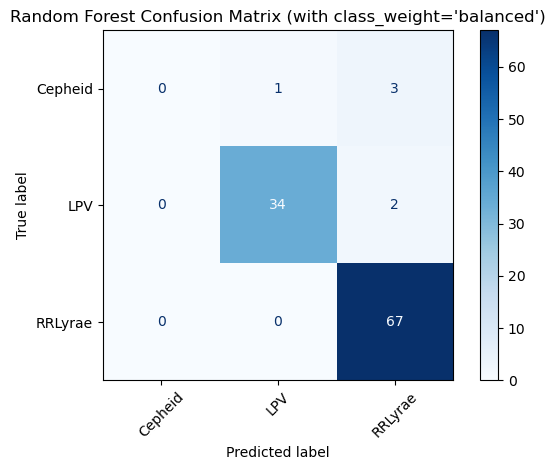


Feature Importances:
r_psfFluxSigma_norm: 0.028
r_red_chi2: 0.053
r_psfFluxStetsonJ: 0.047
r_psfFluxMAD_rel: 0.053
r_psfFluxLinearSlope: 0.043
r_psfFluxMaxSlope: 0.152
r_scienceFluxSigma_norm: 0.049
amp_r: 0.125
r_i: 0.156
W_mag_r_ri: 0.262
Region: 0.009
Class: 0.000
Region__47: 0.018
Region__EDFS: 0.002
Region__Fornax: 0.002


In [58]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    cmap='Blues',
    xticks_rotation=45
)
plt.title("Random Forest Confusion Matrix (with class_weight='balanced')")
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
importances = clf.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")

### Overall Findings: It predicts LPVS and RRLyraes exceptionally well since that comprises a majority of our data, however the very limited cepheids are not predicted well. This is a good start for applying Supervised ML however our training data is NOT representative of the real population of variable stars. We will now move to unsupervised learning as a result.